# Working with complicated dataset

Your name: Emily Leson

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [21]:
import pandas as pd
import urllib.request

URL = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

# Step 1: extract column names robustly
with urllib.request.urlopen(URL) as f:
    for line in f:
        line = line.decode("utf-8").strip().strip('"')
        if line.startswith("# Fields:"):
            fields_str = line.replace("# Fields:", "").strip()
            columns = [c.strip().strip('"') for c in fields_str.split(",") if c.strip().strip('"')]
            break

# Step 2: read only the first len(columns) columns
df = pd.read_csv(URL, comment="#", header=None, names=columns, usecols=range(len(columns)))

# Step 3: drop 'query acc.ver', set 'subject acc.ver' as index
df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")

# Step 4: clean bonds — strip non-digits, coerce to numeric (keeps NaN as NaN), 
#          then cast to nullable integer type Int64 (capital I) which supports NaN
df["bonds"] = (
    df["bonds"]
    .astype(str)
    .str.replace(r"[^\d]", "", regex=True)  # remove commas, quotes, spaces
    .replace("", pd.NA)                      # empty strings → NA
    .astype("Int64")                         # nullable integer (capital I)
)

# Step 5: coerce publications ("-" entries become NaN)
df["publications"] = pd.to_numeric(df["publications"], errors="coerce")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487,9.0
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947,47.0
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106,13.0
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319,41.0


### Question 2
What is the average number of publications?

In [22]:
df["publications"].mean()


np.float64(26.989690721649485)

### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [23]:
df[df["bonds"] > 15000].index.tolist()


['AGK29621.1',
 'AHG32084.1',
 '6G2J_H',
 'YP_002791042.1',
 'AGK29634.1',
 '0806162F',
 'YP_009112408.1',
 'YP_001876469.1',
 'YP_009092269.1',
 'AHG32149.1',
 'YP_009092074.1',
 'YP_009450474.1',
 'YP_004123270.1',
 'YP_009092073.1',
 'AHZ60901.1',
 'YP_004123350.1',
 'YP_009453754.1',
 'ADD46492.1',
 'YP_007025968.1',
 'YP_009453806.1',
 'YP_007024956.1',
 'ASM92364.1',
 'YP_006073044.1',
 'ASM92494.1',
 'ADG95699.1',
 'YP_004891275.1',
 'YP_009166014.1',
 'YP_009538416.1',
 'YP_009414182.1',
 'YP_009178854.1',
 'YP_009414415.1',
 'YP_009353908.1',
 'YP_009093743.1',
 'ABX45285.1',
 'YP_009414156.1',
 'YP_009414363.1']

### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

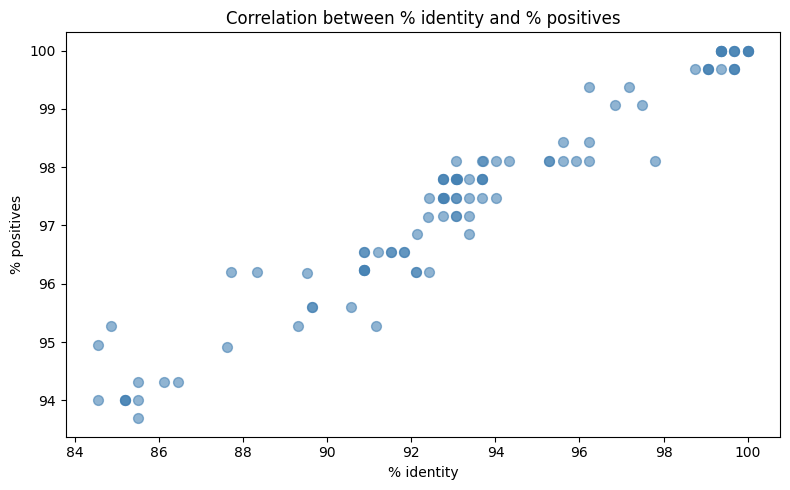

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(df["% identity"], df["% positives"], alpha=0.6, color="steelblue", s=50)
plt.xlabel("% identity")
plt.ylabel("% positives")
plt.title("Correlation between % identity and % positives")
plt.tight_layout()
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [28]:
PROTEIN_URL = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(PROTEIN_URL, index_col=0)

df = df.merge(
    protein_df[["Protein", "Source"]].rename(columns={"Source": "Protein source"}),
    left_index=True,
    right_on="Protein",
    how="left"
)
df = df.drop(columns=["Protein"])
df.index.name = "subject acc.ver"
df["Protein source"] = df["Protein source"].fillna("NA")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,NA
0.0,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487,9.0,RefSeq
NaN,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947,47.0,NA
2.0,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106,13.0,GenPept
NaN,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319,41.0,NA
